# NDJF Cluster Validation and Significance

This notebook validates the exploratory `k = 2, 3, 4` clustering results from `Notebook 08`.

Primary goals:
- test whether the observed cluster silhouettes are stronger than shuffled-null feature structure
- test whether the cluster solutions are stable under repeated event resampling
- test whether the clusters differ on external variables that were not used directly in the clustering
- directly evaluate whether the `k = 3` split between cluster 2 and cluster 3 is statistically meaningful on outside variables
- summarize how the tested `k` values compare in breadth, silhouette rank, stability, and external separation


In [1]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = True
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )
else:
    print("Using existing repo clone:", REPO_DIR)

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print("Working directory:", os.getcwd())


Mounted at /content/drive
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs

Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog


In [2]:
from itertools import combinations
from pathlib import Path
import shutil

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.satellite import default_modis_layers_for_date
from jpcz_catalog.subtypes import (
    benjamini_hochberg_adjust,
    compute_cluster_kruskal_wallis_table,
    compute_pairwise_mannwhitney_table,
    compute_permutation_silhouette_null,
    compute_resampled_cluster_stability,
    feature_definitions_dataframe,
    standardize_feature_table,
)

FEATURE_TABLE_PATH = Path("outputs/verification/jpcz_catalog_ndjf_objective_subtype_features.csv")
RUN_EXPORT_DIR_08 = Path("outputs/verification/objective_subtype_runs")
VALIDATION_EXPORT_DIR = Path("outputs/verification/objective_subtype_validation")
VALIDATION_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_subtype_validation_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
QUICKLOOK_DIR = Path("outputs/verification/ndjf_event_quicklooks_merged_12h")
SATELLITE_DIR = Path("outputs/verification/ndjf_event_satellite_panels_merged_12h")
OLR_DIR = Path("outputs/verification/ndjf_event_olr_panels_merged_12h")

CLUSTER_FEATURE_COLUMNS = [
    "coastal_to_jpcz_mean_divergence_ratio",
    "hokkaido_min_z850_anomaly_tminus12_to_tplus12",
    "front_box_max_temp_gradient_850_tminus12_to_tplus12",
    "sea_of_japan_mean_vorticity_peak_925",
]
VALIDATION_K_VALUES = [2, 3, 4]
PRIMARY_VALIDATION_K = 3
CLUSTER_METHOD = "ward"
N_PERMUTATIONS = 200
N_RESAMPLES = 200
SAMPLE_FRACTION = 0.8
RANDOM_SEED = 42
REPRESENTATIVE_EVENTS_PER_CLUSTER = 5
DISPLAY_REPRESENTATIVE_EVENTS_PER_CLUSTER = 1

EXTERNAL_VALIDATION_COLUMNS = [
    "pacific_to_jpcz_mean_divergence_ratio",
    "sea_of_japan_min_z850_anomaly_tminus12_to_tplus12",
    "pacific_box_max_temp_gradient_850_tminus12_to_tplus12",
    "jpcz_polygon_min_divergence_peak_925",
    "duration_hours",
    "event_peak_D_1e5_s-1",
]

def ordinal_word(value: int) -> str:
    lookup = {1: "first", 2: "second", 3: "third", 4: "fourth", 5: "fifth"}
    return lookup.get(value, f"{value}th")


def size_rank_descriptor(rank: int, total: int) -> str:
    if total <= 1:
        return "only subgroup"
    if rank == 1:
        return "largest subgroup"
    if rank == total:
        return "smallest subgroup"
    return f"{ordinal_word(rank)}-largest subgroup"


def build_cluster_labels_from_counts(cluster_counts: pd.Series | dict[int, int]):
    counts_dict = {int(cluster_id): int(n_events) for cluster_id, n_events in dict(cluster_counts).items()}
    ranked = sorted(counts_dict.items(), key=lambda item: (-item[1], item[0]))
    rank_lookup = {cluster_id: rank for rank, (cluster_id, _) in enumerate(ranked, start=1)}
    total = len(ranked)
    long_labels = {}
    short_labels = {}
    rows = []
    for cluster_id, n_events in sorted(counts_dict.items()):
        descriptor = size_rank_descriptor(rank_lookup[cluster_id], total)
        long_labels[cluster_id] = f"Cluster {cluster_id}: n={n_events} ({descriptor})"
        short_labels[cluster_id] = descriptor
        rows.append(
            {
                "cluster_id": cluster_id,
                "n_events": n_events,
                "size_rank": int(rank_lookup[cluster_id]),
                "size_descriptor": descriptor,
                "cluster_label": long_labels[cluster_id],
            }
        )
    return long_labels, short_labels, pd.DataFrame(rows)


def infer_pairwise_pairs_from_nesting(nesting_counts: pd.DataFrame) -> list[tuple[int, int]]:
    pairs = set()
    for _, row in nesting_counts.iterrows():
        active_clusters = [int(cluster_id) for cluster_id, value in row.items() if float(value) > 0]
        if len(active_clusters) > 1:
            for left_cluster, right_cluster in combinations(active_clusters, 2):
                pairs.add((int(left_cluster), int(right_cluster)))
    return sorted(pairs)


def describe_k_solution(run_k: int, *, tested_k_values: list[int], silhouette_rank: int, is_primary_validation: bool) -> str:
    descriptors = []
    if run_k == tested_k_values[0]:
        descriptors.append("broadest tested partition")
    if run_k == tested_k_values[-1]:
        descriptors.append("most detailed tested partition")
    if int(silhouette_rank) == 1:
        descriptors.append("highest silhouette among tested k")
    else:
        descriptors.append(f"silhouette rank {int(silhouette_rank)} of {len(tested_k_values)}")
    if is_primary_validation:
        descriptors.append("Notebook 09 focus solution")
    return "; ".join(descriptors)


FEATURE_DICTIONARY = feature_definitions_dataframe()
FEATURE_UNITS = FEATURE_DICTIONARY.set_index("column_name")["units"].to_dict()


def maybe_copy_to_drive(path: Path):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        print("Copied to Drive:", drive_path)


def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive:", drive_path, "->", path)
    return True


def axis_label(column_name: str) -> str:
    units = FEATURE_UNITS.get(column_name)
    if units is None or units == "unitless":
        return column_name
    return f"{column_name}\n[{units}]"


def quicklook_name_for_row(row_index: int, row: pd.Series) -> str:
    return f"{pd.Timestamp(row['event_peak']).strftime('%Y%m%dT%H%M')}_idx{row_index:03d}.png"


def satellite_name_for_row(row_index: int, row: pd.Series) -> str | None:
    satellite_layers = default_modis_layers_for_date(pd.Timestamp(row['event_peak']).normalize())
    if not satellite_layers:
        return None
    satellite_layer = satellite_layers[0]
    layer_slug = (
        satellite_layer.replace("MODIS_", "")
        .replace("_CorrectedReflectance_TrueColor", "")
        .lower()
    )
    return f"{pd.Timestamp(row['event_peak']).strftime('%Y%m%dT%H%M')}_idx{row_index:03d}_{layer_slug}.jpg"


def ensure_local_copy(local_path: Path, drive_subdir_name: str) -> bool:
    if local_path.exists():
        return True
    drive_path = Path(DRIVE_OUTPUT_DIR) / drive_subdir_name / local_path.name
    if not drive_path.exists():
        return False
    local_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, local_path)
    return True


In [3]:
paths_to_restore = [
    FEATURE_TABLE_PATH,
    RUN_EXPORT_DIR_08 / "cluster_comparison_summary.csv",
    RUN_EXPORT_DIR_08 / "cluster_medians_comparison_long.csv",
    RUN_EXPORT_DIR_08 / "cluster_counts_comparison.csv",
]
for run_k in VALIDATION_K_VALUES:
    paths_to_restore.extend(
        [
            RUN_EXPORT_DIR_08 / f"clustered_events_k{run_k}.csv",
            RUN_EXPORT_DIR_08 / f"cluster_medians_k{run_k}.csv",
            RUN_EXPORT_DIR_08 / f"cluster_counts_k{run_k}.csv",
            RUN_EXPORT_DIR_08 / f"cluster_quality_selected_k{run_k}.csv",
        ]
    )

for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

feature_df = pd.read_csv(FEATURE_TABLE_PATH)
standardized_df, feature_means, feature_stds = standardize_feature_table(
    feature_df.copy(),
    columns=CLUSTER_FEATURE_COLUMNS,
)

clustered_runs = {}
cluster_columns = {}
cluster_counts_lookup = {}
cluster_quality_lookup = {}

for run_k in VALIDATION_K_VALUES:
    run_path = RUN_EXPORT_DIR_08 / f"clustered_events_k{run_k}.csv"
    if not run_path.exists():
        raise FileNotFoundError(f"Missing clustered run file: {run_path}")
    run_df = pd.read_csv(run_path)
    run_df = add_japan_local_time_columns(run_df)
    cluster_col = [c for c in run_df.columns if c.startswith("cluster_")][-1]
    expected = f"cluster_{CLUSTER_METHOD}_{run_k}"
    if cluster_col != expected:
        raise RuntimeError(f"Expected {expected} in {run_path.name}, found {cluster_col}")
    clustered_runs[run_k] = run_df
    cluster_columns[run_k] = cluster_col
    cluster_counts_lookup[run_k] = run_df[cluster_col].value_counts().sort_index().rename("n_events")

    quality_path = RUN_EXPORT_DIR_08 / f"cluster_quality_selected_k{run_k}.csv"
    if quality_path.exists():
        cluster_quality_lookup[run_k] = pd.read_csv(quality_path)
    else:
        cluster_quality_lookup[run_k] = None

loaded_summary_df = pd.DataFrame(
    {
        "k": VALIDATION_K_VALUES,
        "cluster_column": [cluster_columns[k] for k in VALIDATION_K_VALUES],
        "n_events": [int(cluster_counts_lookup[k].sum()) for k in VALIDATION_K_VALUES],
        "n_clusters_found": [int(cluster_counts_lookup[k].shape[0]) for k in VALIDATION_K_VALUES],
    }
)
print("Loaded cached clustering outputs from Notebook 08")
display(loaded_summary_df)

k2_cluster_col = cluster_columns[2]
k3_cluster_col = cluster_columns[3]
k2_vs_k3_nesting_counts = pd.crosstab(
    clustered_runs[2][k2_cluster_col],
    clustered_runs[3][k3_cluster_col],
    dropna=False,
)
k2_vs_k3_nesting_row_fraction = k2_vs_k3_nesting_counts.div(
    k2_vs_k3_nesting_counts.sum(axis=1),
    axis=0,
).round(3)
k2_vs_k3_nesting_counts_path = VALIDATION_EXPORT_DIR / "cluster_nesting_k2_vs_k3_counts.csv"
k2_vs_k3_nesting_fraction_path = VALIDATION_EXPORT_DIR / "cluster_nesting_k2_vs_k3_row_fraction.csv"
k2_vs_k3_nesting_counts.to_csv(k2_vs_k3_nesting_counts_path)
k2_vs_k3_nesting_row_fraction.to_csv(k2_vs_k3_nesting_fraction_path)
maybe_copy_to_drive(k2_vs_k3_nesting_counts_path)
maybe_copy_to_drive(k2_vs_k3_nesting_fraction_path)

print("\nk=2 vs k=3 nesting counts")
display(k2_vs_k3_nesting_counts)
print("\nk=2 vs k=3 nesting row fractions")
display(k2_vs_k3_nesting_row_fraction)
print(
    "A robust broad split should look nested here: the k=3 solution should mostly preserve the main k=2 split, "
    "then subdivide one side rather than inventing a completely different partition."
)
print("Saved nesting tables:")
print("-", k2_vs_k3_nesting_counts_path.name)
print("-", k2_vs_k3_nesting_fraction_path.name)

PRIMARY_CLUSTER_LABELS, PRIMARY_CLUSTER_SHORT_LABELS, primary_cluster_label_df = build_cluster_labels_from_counts(
    cluster_counts_lookup[PRIMARY_VALIDATION_K]
)
PAIRWISE_CLUSTER_PAIRS_BY_K = {
    PRIMARY_VALIDATION_K: infer_pairwise_pairs_from_nesting(k2_vs_k3_nesting_counts)
}
if not PAIRWISE_CLUSTER_PAIRS_BY_K[PRIMARY_VALIDATION_K]:
    primary_cluster_ids = sorted(int(value) for value in cluster_counts_lookup[PRIMARY_VALIDATION_K].index.tolist())
    PAIRWISE_CLUSTER_PAIRS_BY_K[PRIMARY_VALIDATION_K] = list(combinations(primary_cluster_ids, 2))

print("\nMath-based k=3 cluster labels from the current subgroup sizes")
display(primary_cluster_label_df)
print("\nPairwise cluster comparisons inferred from the current k=2 vs k=3 nesting")
print(PAIRWISE_CLUSTER_PAIRS_BY_K[PRIMARY_VALIDATION_K])


Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/jpcz_catalog_ndjf_objective_subtype_features.csv -> outputs/verification/jpcz_catalog_ndjf_objective_subtype_features.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_comparison_summary.csv -> outputs/verification/objective_subtype_runs/cluster_comparison_summary.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_medians_comparison_long.csv -> outputs/verification/objective_subtype_runs/cluster_medians_comparison_long.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_counts_comparison.csv -> outputs/verification/objective_subtype_runs/cluster_counts_comparison.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/clustered_events_k2.csv -> outputs/verification/objective_subtype_runs/clustered_events_k2.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_medians_k2.csv -> outputs/verification/objective_subtype

,k,cluster_column,n_events,n_clusters_found
0,2,cluster_ward_2,201,2
1,3,cluster_ward_3,201,3
2,4,cluster_ward_4,201,4


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_nesting_k2_vs_k3_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_nesting_k2_vs_k3_row_fraction.csv

k=2 vs k=3 nesting counts


cluster_ward_3,1,2,3
cluster_ward_2,,,
1,134,0,0
2,0,20,47



k=2 vs k=3 nesting row fractions


cluster_ward_3,1,2,3
cluster_ward_2,,,
1,1.0,0.000,0.000
2,0.0,0.299,0.701


A robust broad split should look nested here: the k=3 solution should mostly preserve the main k=2 split, then subdivide one side rather than inventing a completely different partition.
Saved nesting tables:
- cluster_nesting_k2_vs_k3_counts.csv
- cluster_nesting_k2_vs_k3_row_fraction.csv


In [4]:
legend_columns = CLUSTER_FEATURE_COLUMNS + EXTERNAL_VALIDATION_COLUMNS
dictionary_columns = ["units", "meaning", "formula", "calculation", "interpretation", "region", "time_window", "purpose"]
dictionary_index = FEATURE_DICTIONARY.set_index("column_name")
present_columns = [column_name for column_name in legend_columns if column_name in dictionary_index.index]
missing_columns = [column_name for column_name in legend_columns if column_name not in dictionary_index.index]

validation_feature_legend_df = (
    dictionary_index.loc[present_columns, dictionary_columns]
    .reset_index()
    .rename(columns={"column_name": "feature_column"})
)

supplemental_rows = {
    "duration_hours": {
        "units": "hours",
        "meaning": "Total event duration in hours from the merged NDJF event catalog.",
        "formula": "event_end - event_start, expressed in catalog hours",
        "calculation": "Use the merged-event duration already stored in the catalog row; this is not recomputed from the subtype feature fields.",
        "interpretation": "Larger values mean a longer-lived event. This is an external validation variable, not one of the four clustering-input features.",
        "region": "catalog-wide event property",
        "time_window": "whole merged event",
        "purpose": "Checks whether cluster groups differ in event persistence without using duration to build the clusters.",
    },
    "event_peak_D_1e5_s-1": {
        "units": "1e-5 s^-1",
        "meaning": "Peak 12 h polygon-mean divergence metric D, scaled by 1e5, from the original detector catalog.",
        "formula": "1e5 * min_t(D_t), where D is the polygon-mean 925 hPa divergence metric",
        "calculation": "Use the stored event-peak detector metric from the catalog. Because D is divergence, more negative values correspond to stronger polygon-mean convergence episodes.",
        "interpretation": "More negative values mean a stronger detector-defined JPCZ event. This is treated here as an external validation variable rather than a clustering-input feature.",
        "region": "original JPCZ polygon",
        "time_window": "event peak only",
        "purpose": "Checks whether the clusters differ in detector-defined event strength without letting D determine the subtype partition.",
    },
}

if missing_columns:
    supplemental_frames = []
    for column_name in missing_columns:
        metadata = supplemental_rows.get(
            column_name,
            {
                "units": "unknown",
                "meaning": f"Validation-only column {column_name}.",
                "formula": "stored catalog column",
                "calculation": "Loaded directly from the saved feature or cluster table.",
                "interpretation": "Interpret relative magnitudes in the context of the source catalog field.",
                "region": "varies",
                "time_window": "varies",
                "purpose": "External validation column not included in the subtype feature dictionary.",
            },
        )
        supplemental_frames.append(pd.DataFrame([{**{"feature_column": column_name}, **metadata}]))
    validation_feature_legend_df = pd.concat([validation_feature_legend_df] + supplemental_frames, ignore_index=True)

validation_feature_legend_df["feature_column"] = pd.Categorical(
    validation_feature_legend_df["feature_column"],
    categories=legend_columns,
    ordered=True,
)
validation_feature_legend_df = validation_feature_legend_df.sort_values("feature_column").reset_index(drop=True)
validation_feature_legend_df.insert(
    1,
    "plot_label",
    [axis_label(column_name) for column_name in validation_feature_legend_df["feature_column"]],
)
validation_feature_legend_path = VALIDATION_EXPORT_DIR / "validation_feature_legend.csv"
validation_feature_legend_df.to_csv(validation_feature_legend_path, index=False)
maybe_copy_to_drive(validation_feature_legend_path)

print("Validation feature legend")
display(validation_feature_legend_df)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/validation_feature_legend.csv
Validation feature legend


,feature_column,plot_label,units,meaning,formula,calculation,interpretation,region,time_window,purpose
0,coastal_to_jpcz_mean_divergence_ratio,coastal_to_jpcz_mean_divergence_ratio,unitless,Ratio of coastal-Japan mean signed divergence ...,coastal_japan_mean_divergence_peak_925 / jpcz_...,coastal_japan_mean_divergence_peak_925 / jpcz_...,"When both regional means are negative, values ...",Coastal Japan vs JPCZ polygon,event peak only,Measures how the coastal signed-divergence mea...
1,hokkaido_min_z850_anomaly_tminus12_to_tplus12,hokkaido_min_z850_anomaly_tminus12_to_tplus12\...,gpm,Most negative 850 hPa geopotential-height anom...,"min_{t in [-12,0,+12]} min_hokkaido(z850_event...",Compute z850 anomaly as event-time z850 minus ...,More negative values indicate a deeper passing...,Hokkaido box,"t-12 h, t0, t+12 h",Quantifies passing-low or trough forcing near ...
2,front_box_max_temp_gradient_850_tminus12_to_tp...,front_box_max_temp_gradient_850_tminus12_to_tp...,K (100 km)^-1,Largest 850 hPa horizontal temperature-gradien...,"max_{t in [-12,0,+12]} max_front(|grad T850(t)...",Compute |grad T850| and save the maximum box v...,Larger values indicate stronger frontal or bar...,Hokkaido front box,"t-12 h, t0, t+12 h",Quantifies frontal or baroclinic forcing upstr...
3,sea_of_japan_mean_vorticity_peak_925,sea_of_japan_mean_vorticity_peak_925\n[1e-5 s^-1],1e-5 s^-1,Area-weighted mean relative vorticity in the S...,"mean_soj(zeta925), where zeta925 = dv/dx - du/dy",Compute 925 hPa relative vorticity from ERA5 u...,More positive values indicate stronger cycloni...,Sea of Japan box,event peak only,Quantifies circulation-centered forcing over t...
4,pacific_to_jpcz_mean_divergence_ratio,pacific_to_jpcz_mean_divergence_ratio,unitless,Ratio of Pacific-box mean signed divergence to...,pacific_east_of_japan_mean_divergence_peak_925...,pacific_east_of_japan_mean_divergence_peak_925...,"When both regional means are negative, values ...",Pacific east of Japan vs JPCZ polygon,event peak only,Measures how strongly the event is coupled to ...
5,sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,sea_of_japan_min_z850_anomaly_tminus12_to_tplu...,gpm,Most negative 850 hPa geopotential-height anom...,"min_{t in [-12,0,+12]} min_soj(z850_event(t) -...","Same anomaly logic as above, but evaluated in ...",More negative values indicate a deeper synopti...,Sea of Japan box,"t-12 h, t0, t+12 h",Quantifies whether the synoptic-height depress...
6,pacific_box_max_temp_gradient_850_tminus12_to_...,pacific_box_max_temp_gradient_850_tminus12_to_...,K (100 km)^-1,Largest 850 hPa horizontal temperature-gradien...,"max_{t in [-12,0,+12]} max_pacific_front(|grad...",Compute |grad T850| and save the maximum Pacif...,Larger values indicate stronger frontal or bar...,Pacific front box,"t-12 h, t0, t+12 h",Quantifies frontal or baroclinic forcing east ...
7,jpcz_polygon_min_divergence_peak_925,jpcz_polygon_min_divergence_peak_925\n[1e-5 s^-1],1e-5 s^-1,Most negative signed divergence value in the o...,min_polygon(div925),Minimum of the signed divergence field inside ...,More negative values mean a stronger local con...,Original JPCZ polygon,event peak only,Captures the strongest local convergence cente...
8,duration_hours,duration_hours,hours,Total event duration in hours from the merged ...,"event_end - event_start, expressed in catalog ...",Use the merged-event duration already stored i...,Larger values mean a longer-lived event. This ...,catalog-wide event property,whole merged event,Checks whether cluster groups differ in event ...
9,event_peak_D_1e5_s-1,event_peak_D_1e5_s-1,1e-5 s^-1,"Peak 12 h polygon-mean divergence metric D, sc...","1e5 * min_t(D_t), where D is the polygon-mean ...",Use the stored event-peak detector metric from...,More negative values mean a stronger detector-...,original JPCZ polygon,event peak only,Checks whether the clusters differ in detector...


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/silhouette_permutation_null_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/silhouette_permutation_null_k3.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/silhouette_permutation_null_k4.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/permutation_null_silhouette_histograms.png


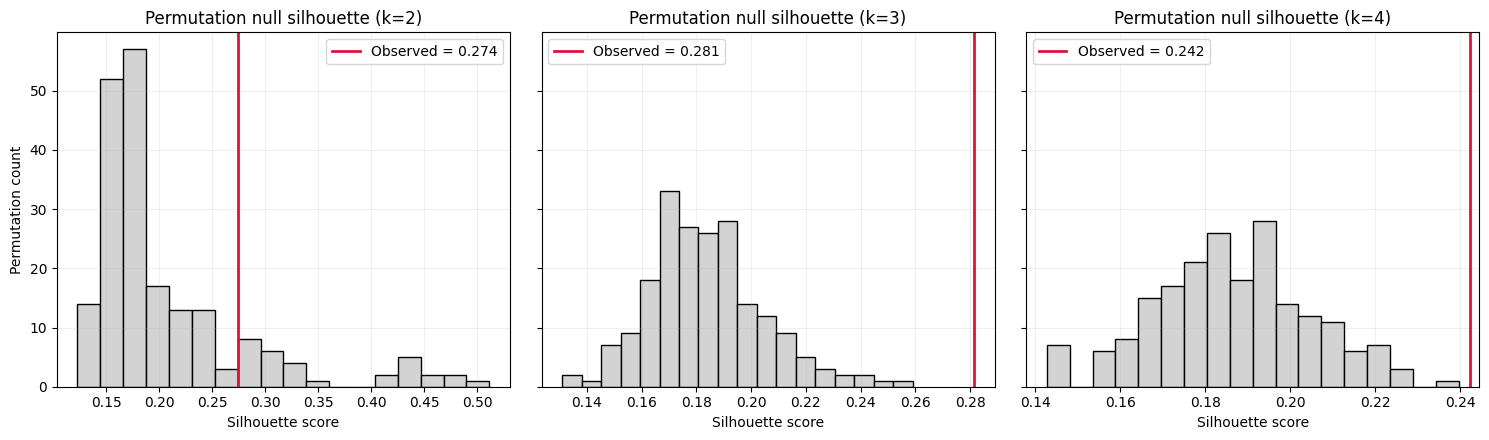

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/silhouette_permutation_summary.csv
Permutation silhouette summary


,k,observed_silhouette,null_mean_silhouette,null_std_silhouette,silhouette_minus_null_mean,silhouette_z_effect,empirical_p_value,n_permutations
0,2,0.273980,0.206831,0.078089,0.067148,0.859894,0.159204,200
1,3,0.281360,0.183534,0.021155,0.097825,4.624164,0.004975,200
2,4,0.242252,0.186657,0.018315,0.055595,3.035528,0.004975,200


In [5]:
permutation_rows = []
fig, axes = plt.subplots(1, len(VALIDATION_K_VALUES), figsize=(5 * len(VALIDATION_K_VALUES), 4.5), sharey=True)
if len(VALIDATION_K_VALUES) == 1:
    axes = [axes]

for ax, run_k in zip(axes, VALIDATION_K_VALUES):
    permutation_df = compute_permutation_silhouette_null(
        standardized_df,
        n_clusters=run_k,
        method=CLUSTER_METHOD,
        n_permutations=N_PERMUTATIONS,
        random_seed=RANDOM_SEED,
    )
    permutation_path = VALIDATION_EXPORT_DIR / f"silhouette_permutation_null_k{run_k}.csv"
    permutation_df.to_csv(permutation_path, index=False)
    maybe_copy_to_drive(permutation_path)

    observed_score = float(permutation_df.loc[permutation_df["kind"] == "observed", "silhouette_score"].iloc[0])
    null_scores = permutation_df.loc[permutation_df["kind"] == "permuted", "silhouette_score"].to_numpy(dtype=float)
    null_mean = float(np.mean(null_scores))
    null_std = float(np.std(null_scores, ddof=1)) if len(null_scores) > 1 else float("nan")
    empirical_p_value = float(((null_scores >= observed_score).sum() + 1) / (len(null_scores) + 1))
    z_effect = float((observed_score - null_mean) / null_std) if np.isfinite(null_std) and null_std > 0 else float("nan")

    permutation_rows.append(
        {
            "k": run_k,
            "observed_silhouette": observed_score,
            "null_mean_silhouette": null_mean,
            "null_std_silhouette": null_std,
            "silhouette_minus_null_mean": observed_score - null_mean,
            "silhouette_z_effect": z_effect,
            "empirical_p_value": empirical_p_value,
            "n_permutations": N_PERMUTATIONS,
        }
    )

    ax.hist(null_scores, bins=18, color="lightgray", edgecolor="black")
    ax.axvline(observed_score, color="crimson", linewidth=2.0, label=f"Observed = {observed_score:.3f}")
    ax.set_title(f"Permutation null silhouette (k={run_k})")
    ax.set_xlabel("Silhouette score")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")

axes[0].set_ylabel("Permutation count")
fig.tight_layout()
permutation_plot_path = PLOT_DIR / "permutation_null_silhouette_histograms.png"
fig.savefig(permutation_plot_path, dpi=170, bbox_inches="tight")
maybe_copy_to_drive(permutation_plot_path)
plt.show()

permutation_summary_df = pd.DataFrame(permutation_rows).sort_values("k").reset_index(drop=True)
permutation_summary_path = VALIDATION_EXPORT_DIR / "silhouette_permutation_summary.csv"
permutation_summary_df.to_csv(permutation_summary_path, index=False)
maybe_copy_to_drive(permutation_summary_path)

print("Permutation silhouette summary")
display(permutation_summary_df)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_stability_resamples_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_stability_resamples_k3.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_stability_resamples_k4.csv


/tmp/ipykernel_435/4171626958.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"k={run_k}" for run_k in VALIDATION_K_VALUES], showmeans=True)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_stability_ari_boxplot.png


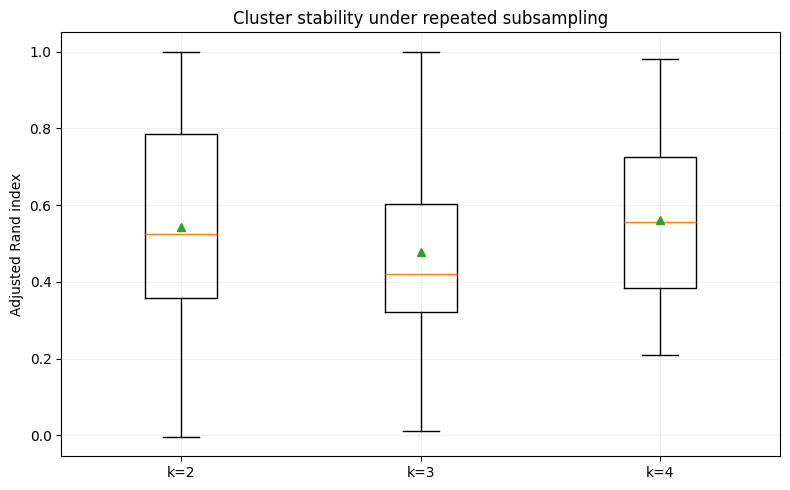

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_stability_summary.csv
Resampling stability summary


,k,n_resamples,sample_fraction,mean_adjusted_rand_index,median_adjusted_rand_index,p10_adjusted_rand_index,p90_adjusted_rand_index,mean_subset_silhouette
0,2,200,0.8,0.542763,0.525230,0.205683,0.901287,0.284089
1,3,200,0.8,0.477052,0.421091,0.246670,0.873362,0.240856
2,4,200,0.8,0.560968,0.555067,0.317180,0.842755,0.227902


In [6]:
stability_rows = []
stability_frames = []

for run_k in VALIDATION_K_VALUES:
    stability_df = compute_resampled_cluster_stability(
        standardized_df,
        n_clusters=run_k,
        method=CLUSTER_METHOD,
        n_resamples=N_RESAMPLES,
        sample_fraction=SAMPLE_FRACTION,
        random_seed=RANDOM_SEED,
    )
    stability_df.insert(0, "k", run_k)
    stability_frames.append(stability_df)

    stability_path = VALIDATION_EXPORT_DIR / f"cluster_stability_resamples_k{run_k}.csv"
    stability_df.to_csv(stability_path, index=False)
    maybe_copy_to_drive(stability_path)

    stability_rows.append(
        {
            "k": run_k,
            "n_resamples": N_RESAMPLES,
            "sample_fraction": SAMPLE_FRACTION,
            "mean_adjusted_rand_index": float(stability_df["adjusted_rand_index"].mean()),
            "median_adjusted_rand_index": float(stability_df["adjusted_rand_index"].median()),
            "p10_adjusted_rand_index": float(stability_df["adjusted_rand_index"].quantile(0.10)),
            "p90_adjusted_rand_index": float(stability_df["adjusted_rand_index"].quantile(0.90)),
            "mean_subset_silhouette": float(stability_df["subset_silhouette_score"].mean()),
        }
    )

stability_all_df = pd.concat(stability_frames, ignore_index=True)
stability_summary_df = pd.DataFrame(stability_rows).sort_values("k").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
data = [stability_all_df.loc[stability_all_df["k"] == run_k, "adjusted_rand_index"].to_numpy() for run_k in VALIDATION_K_VALUES]
ax.boxplot(data, labels=[f"k={run_k}" for run_k in VALIDATION_K_VALUES], showmeans=True)
ax.set_ylabel("Adjusted Rand index")
ax.set_title("Cluster stability under repeated subsampling")
ax.grid(alpha=0.2)
fig.tight_layout()
stability_plot_path = PLOT_DIR / "cluster_stability_ari_boxplot.png"
fig.savefig(stability_plot_path, dpi=170, bbox_inches="tight")
maybe_copy_to_drive(stability_plot_path)
plt.show()

stability_summary_path = VALIDATION_EXPORT_DIR / "cluster_stability_summary.csv"
stability_summary_df.to_csv(stability_summary_path, index=False)
maybe_copy_to_drive(stability_summary_path)

print("Resampling stability summary")
display(stability_summary_df)


In [7]:
external_rows = []
external_significant_frames = []
external_medians_lookup = {}

for run_k in VALIDATION_K_VALUES:
    run_df = clustered_runs[run_k]
    cluster_col = cluster_columns[run_k]
    kw_df = compute_cluster_kruskal_wallis_table(
        run_df,
        cluster_column=cluster_col,
        variables=EXTERNAL_VALIDATION_COLUMNS,
    )
    kw_df.insert(0, "k", run_k)
    kw_df["bh_q_value"] = benjamini_hochberg_adjust(kw_df["p_value"])
    external_rows.append(kw_df)

    external_path = VALIDATION_EXPORT_DIR / f"external_validation_kruskal_k{run_k}.csv"
    kw_df.to_csv(external_path, index=False)
    maybe_copy_to_drive(external_path)

    medians_df = run_df.groupby(cluster_col)[EXTERNAL_VALIDATION_COLUMNS].median().round(2)
    external_medians_lookup[run_k] = medians_df
    medians_path = VALIDATION_EXPORT_DIR / f"external_validation_medians_k{run_k}.csv"
    medians_df.to_csv(medians_path)
    maybe_copy_to_drive(medians_path)

    external_significant_frames.append(kw_df.loc[kw_df["bh_q_value"] <= 0.05].copy())

external_validation_df = pd.concat(external_rows, ignore_index=True)
external_validation_path = VALIDATION_EXPORT_DIR / "external_validation_kruskal_all_k.csv"
external_validation_df.to_csv(external_validation_path, index=False)
maybe_copy_to_drive(external_validation_path)

external_significant_df = pd.concat(external_significant_frames, ignore_index=True) if external_significant_frames else pd.DataFrame()
external_significant_path = VALIDATION_EXPORT_DIR / "external_validation_kruskal_significant.csv"
external_significant_df.to_csv(external_significant_path, index=False)
maybe_copy_to_drive(external_significant_path)

print("External-variable Kruskal-Wallis summary across k=2,3,4")
display(external_validation_df)
print(f"\nExternal-variable medians for primary validation solution k={PRIMARY_VALIDATION_K}")
display(external_medians_lookup[PRIMARY_VALIDATION_K])


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_kruskal_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_medians_k2.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_kruskal_k3.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_medians_k3.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_kruskal_k4.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_medians_k4.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_kruskal_all_k.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/external_validation_kruskal_significant.csv
External-variable Kruskal-Wallis summary across k=2,3,4


,k,cluster_column,variable,n_groups,n_complete_rows,kruskal_statistic,p_value,bh_q_value
0,2,cluster_ward_2,pacific_to_jpcz_mean_divergence_ratio,2,201,0.002389,9.610196e-01,9.610196e-01
1,2,cluster_ward_2,sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,2,201,65.572195,5.602361e-16,3.361417e-15
2,2,cluster_ward_2,pacific_box_max_temp_gradient_850_tminus12_to_...,2,201,1.700851,1.921768e-01,2.882651e-01
3,2,cluster_ward_2,jpcz_polygon_min_divergence_peak_925,2,201,9.784022,1.760348e-03,5.281045e-03
4,2,cluster_ward_2,duration_hours,2,201,3.892119,4.851318e-02,9.702636e-02
5,2,cluster_ward_2,event_peak_D_1e5_s-1,2,201,0.014617,9.037710e-01,9.610196e-01
6,3,cluster_ward_3,pacific_to_jpcz_mean_divergence_ratio,3,201,1.259948,5.326056e-01,5.326056e-01
7,3,cluster_ward_3,sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,3,201,65.847404,5.028263e-15,3.016958e-14
8,3,cluster_ward_3,pacific_box_max_temp_gradient_850_tminus12_to_...,3,201,6.876237,3.212507e-02,3.855009e-02
9,3,cluster_ward_3,jpcz_polygon_min_divergence_peak_925,3,201,9.824833,7.354693e-03,1.103204e-02



External-variable medians for primary validation solution k=3


,pacific_to_jpcz_mean_divergence_ratio,sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,pacific_box_max_temp_gradient_850_tminus12_to_tplus12,jpcz_polygon_min_divergence_peak_925,duration_hours,event_peak_D_1e5_s-1
cluster_ward_3,,,,,,
1,0.09,-92.51,7.96,-15.40,10.0,-2.76
2,0.16,-186.81,9.63,-17.76,12.0,-3.21
3,0.06,-164.91,7.73,-17.78,8.0,-2.59


In [8]:
pairwise_frames = []
for run_k, cluster_pairs in PAIRWISE_CLUSTER_PAIRS_BY_K.items():
    run_df = clustered_runs[run_k]
    cluster_col = cluster_columns[run_k]
    pairwise_df = compute_pairwise_mannwhitney_table(
        run_df,
        cluster_column=cluster_col,
        variables=EXTERNAL_VALIDATION_COLUMNS,
        cluster_pairs=cluster_pairs,
    )
    pairwise_df.insert(0, "k", run_k)
    pairwise_df["bh_q_value"] = benjamini_hochberg_adjust(pairwise_df["p_value"])
    pairwise_df["median_difference_right_minus_left"] = pairwise_df["right_median"] - pairwise_df["left_median"]
    pairwise_frames.append(pairwise_df)

    pairwise_path = VALIDATION_EXPORT_DIR / f"pairwise_cluster_checks_k{run_k}.csv"
    pairwise_df.to_csv(pairwise_path, index=False)
    maybe_copy_to_drive(pairwise_path)

pairwise_summary_df = pd.concat(pairwise_frames, ignore_index=True) if pairwise_frames else pd.DataFrame()
pairwise_summary_path = VALIDATION_EXPORT_DIR / "pairwise_cluster_checks_all.csv"
pairwise_summary_df.to_csv(pairwise_summary_path, index=False)
maybe_copy_to_drive(pairwise_summary_path)

print("Pairwise external-variable checks for selected cluster pairs")
display(pairwise_summary_df)


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/pairwise_cluster_checks_k3.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/pairwise_cluster_checks_all.csv
Pairwise external-variable checks for selected cluster pairs


,k,cluster_column,variable,left_cluster,right_cluster,n_left,n_right,mannwhitney_u,p_value,left_median,right_median,bh_q_value,median_difference_right_minus_left
0,3,cluster_ward_3,pacific_to_jpcz_mean_divergence_ratio,2,3,20,47,542.0,0.327251,0.155535,0.060979,0.392701,-0.094557
1,3,cluster_ward_3,sea_of_japan_min_z850_anomaly_tminus12_to_tplus12,2,3,20,47,393.0,0.294558,-186.808167,-164.905640,0.392701,21.902527
2,3,cluster_ward_3,pacific_box_max_temp_gradient_850_tminus12_to_...,2,3,20,47,639.0,0.020959,9.627219,7.730579,0.041918,-1.896640
3,3,cluster_ward_3,jpcz_polygon_min_divergence_peak_925,2,3,20,47,462.0,0.918152,-17.759848,-17.780134,0.918152,-0.020286
4,3,cluster_ward_3,duration_hours,2,3,20,47,662.0,0.008510,12.000000,8.000000,0.025531,-4.000000
5,3,cluster_ward_3,event_peak_D_1e5_s-1,2,3,20,47,224.0,0.000769,-3.214107,-2.592253,0.004613,0.621854


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_representative_events_validation.csv
Representative k=3 events nearest each cluster centroid


,cluster_id,cluster_label,representative_rank,catalog_index,centroid_distance,event_peak_utc,event_peak_jst,duration_hours,event_peak_D_1e5_s-1,coastal_to_jpcz_mean_divergence_ratio,sea_of_japan_mean_vorticity_peak_925,hokkaido_min_z850_anomaly_tminus12_to_tplus12,front_box_max_temp_gradient_850_tminus12_to_tplus12,pattern_type_manual,verification_notes,quicklook_name,olr_name,satellite_name
0,1,Cluster 1: n=134 (largest subgroup),1,88,0.342151,2008-11-17 22:00:00,2008-11-18 07:00:00,7.0,-2.156160,0.305470,0.343181,-84.335449,14.008179,NaN,NaN,20081117T2200_idx088.png,20081117T2200_idx088.png,20081117T2200_idx088_terra.jpg
1,1,Cluster 1: n=134 (largest subgroup),2,188,0.352943,2017-12-05 02:00:00,2017-12-05 11:00:00,22.0,-3.686154,0.319722,0.283002,-100.210205,13.773792,NaN,not really a system but potentially the remnan...,20171205T0200_idx188.png,20171205T0200_idx188.png,20171205T0200_idx188_terra.jpg
2,1,Cluster 1: n=134 (largest subgroup),3,186,0.453427,2017-11-22 21:00:00,2017-11-23 06:00:00,3.0,-1.935781,0.385148,0.436981,-132.635010,16.555810,NaN,major convergence south of Japan see large scale,20171122T2100_idx186.png,20171122T2100_idx186.png,20171122T2100_idx186_terra.jpg
3,1,Cluster 1: n=134 (largest subgroup),4,19,0.582062,2001-11-25 04:00:00,2001-11-25 13:00:00,6.0,-2.038426,0.223142,0.386108,-130.397583,18.059037,NaN,NaN,20011125T0400_idx019.png,20011125T0400_idx019.png,20011125T0400_idx019_terra.jpg
4,1,Cluster 1: n=134 (largest subgroup),5,189,0.591951,2017-12-16 06:00:00,2017-12-16 15:00:00,11.0,-2.795634,0.630277,0.637554,-66.539795,15.876550,NaN,NaN,20171216T0600_idx189.png,20171216T0600_idx189.png,20171216T0600_idx189_terra.jpg
5,2,Cluster 2: n=20 (smallest subgroup),1,141,0.636261,2013-01-24 18:00:00,2013-01-25 03:00:00,3.0,-2.558489,0.735889,2.206632,-178.355713,34.960864,NaN,interesting se4tup flow is all over the place ...,20130124T1800_idx141.png,20130124T1800_idx141.png,20130124T1800_idx141_terra.jpg
6,2,Cluster 2: n=20 (smallest subgroup),2,59,0.734128,2005-01-31 22:00:00,2005-02-01 07:00:00,23.0,-3.040195,0.534124,2.029169,-258.837524,30.519522,NaN,extends to coastal Japan,20050131T2200_idx059.png,20050131T2200_idx059.png,20050131T2200_idx059_terra.jpg
7,2,Cluster 2: n=20 (smallest subgroup),3,150,0.766254,2013-12-11 08:00:00,2013-12-11 17:00:00,16.0,-3.877621,0.480377,1.481122,-242.640015,32.650259,NaN,NaN,20131211T0800_idx150.png,20131211T0800_idx150.png,20131211T0800_idx150_terra.jpg
8,2,Cluster 2: n=20 (smallest subgroup),4,133,1.085936,2012-12-05 21:00:00,2012-12-06 06:00:00,14.0,-4.132763,0.443791,2.886431,-183.985596,30.978664,NaN,potentially also a system in soj,20121205T2100_idx133.png,20121205T2100_idx133.png,20121205T2100_idx133_terra.jpg
9,2,Cluster 2: n=20 (smallest subgroup),5,103,1.123756,2009-12-31 00:00:00,2009-12-31 09:00:00,13.0,-3.367078,0.448548,1.113704,-239.574951,35.042057,NaN,a system appears to be north of hokkaido,20091231T0000_idx103.png,20091231T0000_idx103.png,20091231T0000_idx103_terra.jpg


Cluster 1: n=134 (largest subgroup)
catalog idx 88 | UTC 2008-11-17 22:00 | JST 2008-11-18 07:00 | centroid distance 0.342
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_representative_panels_cluster1.png


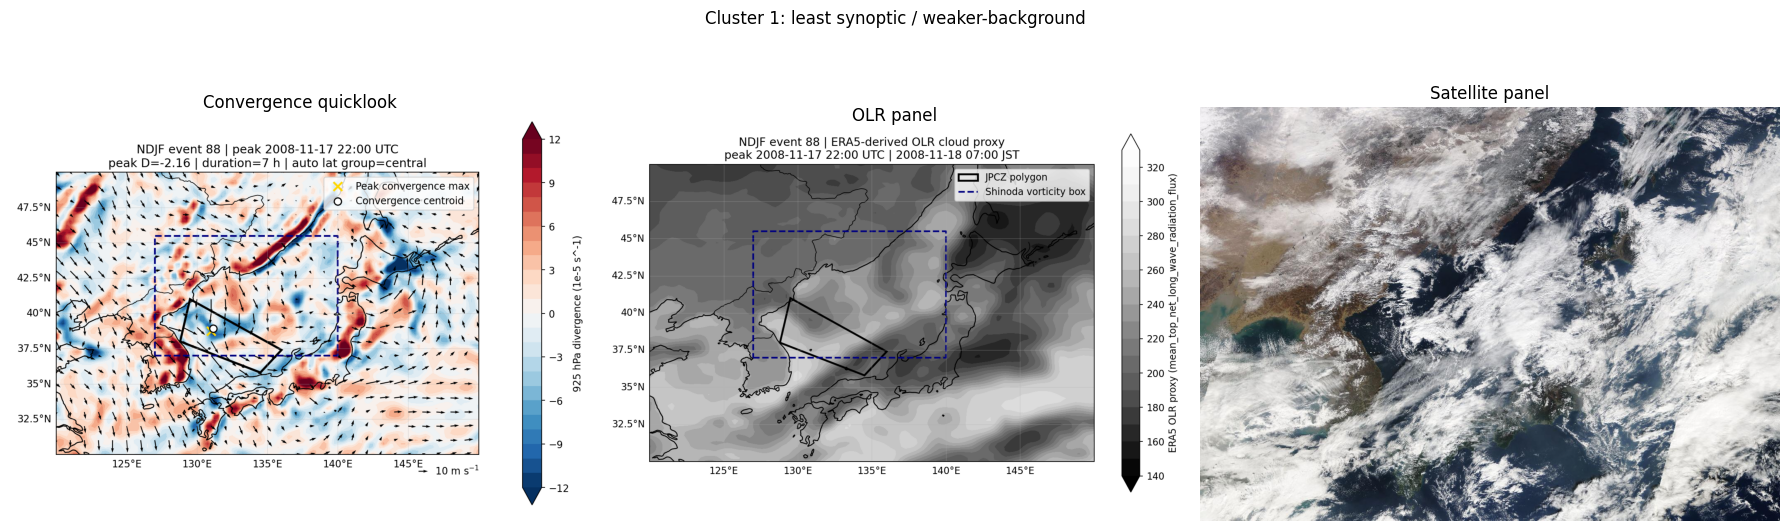

Cluster 2: n=20 (smallest subgroup)
catalog idx 141 | UTC 2013-01-24 18:00 | JST 2013-01-25 03:00 | centroid distance 0.636
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_representative_panels_cluster2.png


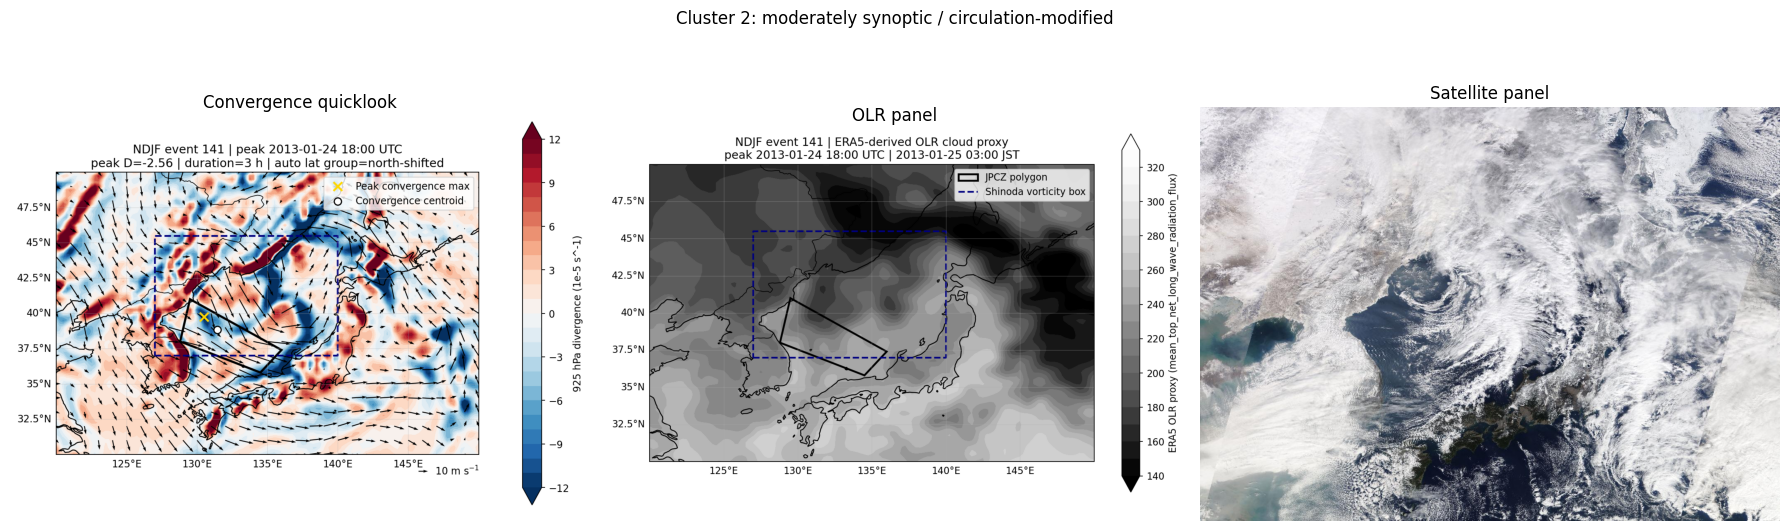

Cluster 3: n=47 (second-largest subgroup)
catalog idx 63 | UTC 2005-11-06 09:00 | JST 2005-11-06 18:00 | centroid distance 0.328
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/k3_representative_panels_cluster3.png


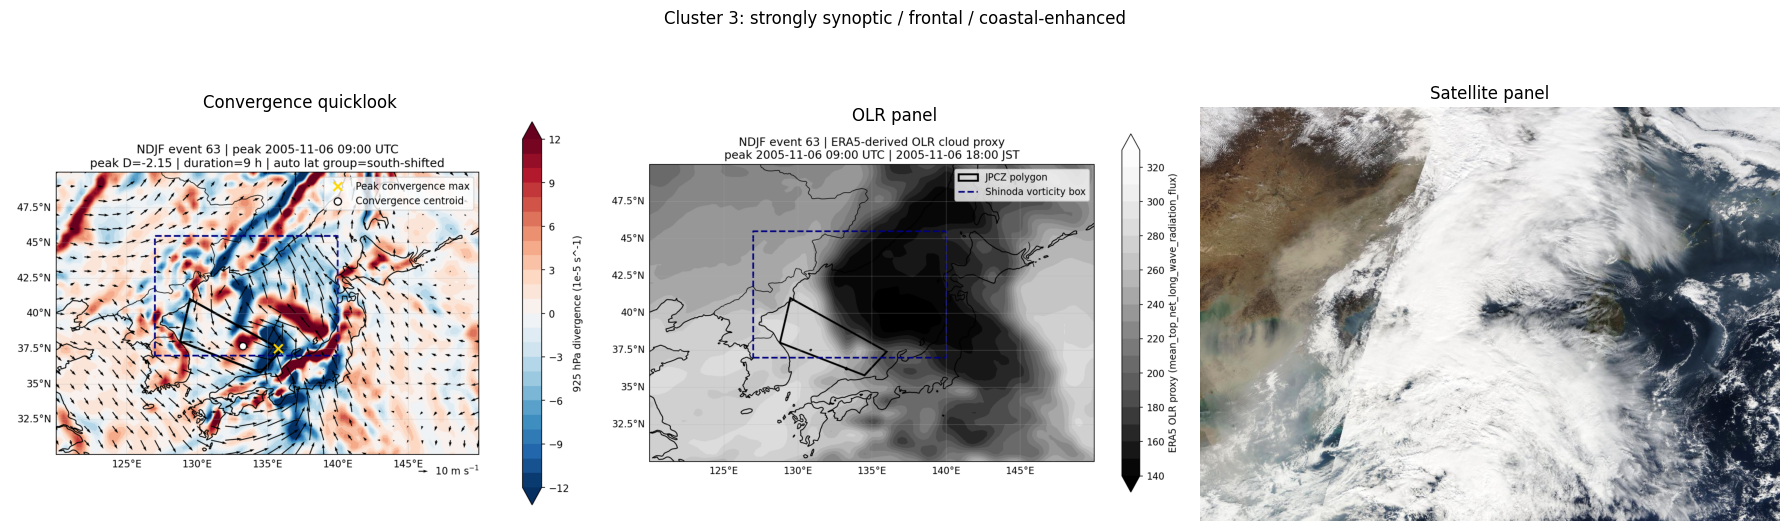

In [9]:
primary_run_df = clustered_runs[PRIMARY_VALIDATION_K].copy()
primary_cluster_col = cluster_columns[PRIMARY_VALIDATION_K]
standardized_primary_df, _, _ = standardize_feature_table(
    primary_run_df.copy(),
    columns=CLUSTER_FEATURE_COLUMNS,
)
valid_mask = standardized_primary_df.notna().all(axis=1) & primary_run_df[primary_cluster_col].notna()
standardized_primary_df = standardized_primary_df.loc[valid_mask].copy()
primary_run_df = primary_run_df.loc[valid_mask].copy()
primary_cluster_labels = primary_run_df[primary_cluster_col].astype(int)
centroids = standardized_primary_df.groupby(primary_cluster_labels).mean()

representative_records = []
for cluster_id in sorted(centroids.index):
    member_index = primary_cluster_labels.index[primary_cluster_labels == cluster_id]
    member_points = standardized_primary_df.loc[member_index]
    centroid = centroids.loc[cluster_id]
    distances = np.sqrt(((member_points - centroid) ** 2).sum(axis=1))
    top_members = distances.sort_values().head(REPRESENTATIVE_EVENTS_PER_CLUSTER)

    for rank_within_cluster, (row_index, centroid_distance) in enumerate(top_members.items(), start=1):
        row = primary_run_df.loc[row_index].copy()
        quicklook_name = quicklook_name_for_row(row_index, row)
        satellite_name = satellite_name_for_row(row_index, row)
        olr_name = quicklook_name
        representative_records.append(
            {
                "cluster_id": int(cluster_id),
                "cluster_label": PRIMARY_CLUSTER_LABELS.get(int(cluster_id), f"Cluster {int(cluster_id)}"),
                "representative_rank": int(rank_within_cluster),
                "catalog_index": int(row_index),
                "centroid_distance": float(centroid_distance),
                "event_peak_utc": pd.Timestamp(row["event_peak"]),
                "event_peak_jst": pd.Timestamp(row["event_peak_jst"]) if pd.notna(row.get("event_peak_jst")) else pd.NaT,
                "duration_hours": float(row["duration_hours"]),
                "event_peak_D_1e5_s-1": float(row["event_peak_D_1e5_s-1"]),
                "coastal_to_jpcz_mean_divergence_ratio": float(row["coastal_to_jpcz_mean_divergence_ratio"]),
                "sea_of_japan_mean_vorticity_peak_925": float(row["sea_of_japan_mean_vorticity_peak_925"]),
                "hokkaido_min_z850_anomaly_tminus12_to_tplus12": float(row["hokkaido_min_z850_anomaly_tminus12_to_tplus12"]),
                "front_box_max_temp_gradient_850_tminus12_to_tplus12": float(row["front_box_max_temp_gradient_850_tminus12_to_tplus12"]),
                "pattern_type_manual": row.get("pattern_type_manual", ""),
                "verification_notes": row.get("verification_notes", ""),
                "quicklook_name": quicklook_name,
                "olr_name": olr_name,
                "satellite_name": satellite_name,
            }
        )

representative_k3_df = pd.DataFrame(representative_records).sort_values(["cluster_id", "representative_rank"]).reset_index(drop=True)
representative_k3_path = VALIDATION_EXPORT_DIR / "k3_representative_events_validation.csv"
representative_k3_df.to_csv(representative_k3_path, index=False)
maybe_copy_to_drive(representative_k3_path)

print("Representative k=3 events nearest each cluster centroid")
display(representative_k3_df)

def display_validation_representative_panels(representative_df: pd.DataFrame, *, per_cluster: int = 1):
    rows_to_show = representative_df.groupby("cluster_id", group_keys=False).head(per_cluster)
    for _, rep in rows_to_show.iterrows():
        print(rep["cluster_label"])
        print(
            f"catalog idx {int(rep['catalog_index'])} | UTC {pd.Timestamp(rep['event_peak_utc']):%Y-%m-%d %H:%M} | "
            f"JST {pd.Timestamp(rep['event_peak_jst']):%Y-%m-%d %H:%M} | centroid distance {rep['centroid_distance']:.3f}"
        )

        panel_specs = [
            ("Convergence quicklook", QUICKLOOK_DIR / rep["quicklook_name"], QUICKLOOK_DIR.name),
            ("OLR panel", OLR_DIR / rep["olr_name"], OLR_DIR.name),
        ]
        if pd.notna(rep["satellite_name"]) and rep["satellite_name"]:
            panel_specs.append(("Satellite panel", SATELLITE_DIR / rep["satellite_name"], SATELLITE_DIR.name))

        fig, axes = plt.subplots(1, len(panel_specs), figsize=(6 * len(panel_specs), 6))
        if len(panel_specs) == 1:
            axes = [axes]

        for ax, (panel_label, local_path, drive_subdir_name) in zip(axes, panel_specs):
            has_panel = ensure_local_copy(local_path, drive_subdir_name)
            if not has_panel:
                ax.axis("off")
                ax.set_title(f"{panel_label}\nmissing")
                continue
            image = mpimg.imread(local_path)
            ax.imshow(image)
            ax.axis("off")
            ax.set_title(panel_label)

        fig.suptitle(rep["cluster_label"], y=0.98)
        fig.tight_layout()
        panel_path = PLOT_DIR / f"k3_representative_panels_cluster{int(rep['cluster_id'])}.png"
        fig.savefig(panel_path, dpi=170, bbox_inches="tight")
        maybe_copy_to_drive(panel_path)
        plt.show()

display_validation_representative_panels(
    representative_k3_df,
    per_cluster=DISPLAY_REPRESENTATIVE_EVENTS_PER_CLUSTER,
)


In [10]:
comparison_summary_path = RUN_EXPORT_DIR_08 / "cluster_comparison_summary.csv"
if comparison_summary_path.exists():
    cluster_comparison_df = pd.read_csv(comparison_summary_path)
else:
    cluster_comparison_df = pd.DataFrame({"k": VALIDATION_K_VALUES})

final_summary_df = cluster_comparison_df.merge(permutation_summary_df, on="k", how="left")
final_summary_df = final_summary_df.merge(stability_summary_df, on="k", how="left")
final_summary_df["cluster_counts"] = final_summary_df["k"].map(
    lambda run_k: ", ".join(
        f"{int(cluster_id)}:{int(n_events)}" for cluster_id, n_events in cluster_counts_lookup[run_k].items()
    )
)
final_summary_df["primary_external_significant_count"] = final_summary_df["k"].map(
    lambda run_k: int((external_validation_df["k"].eq(run_k) & (external_validation_df["bh_q_value"] <= 0.05)).sum())
)
tested_k_values = sorted(int(value) for value in final_summary_df["k"].tolist())
final_summary_df["recommended_role"] = final_summary_df.apply(
    lambda row: describe_k_solution(
        int(row["k"]),
        tested_k_values=tested_k_values,
        silhouette_rank=int(row["silhouette_rank"]),
        is_primary_validation=bool(int(row["k"]) == PRIMARY_VALIDATION_K),
    ),
    axis=1,
)

final_summary_path = VALIDATION_EXPORT_DIR / "cluster_validation_summary.csv"
final_summary_df.to_csv(final_summary_path, index=False)
maybe_copy_to_drive(final_summary_path)

best_silhouette_k = int(final_summary_df.loc[final_summary_df["silhouette_rank"] == 1, "k"].iloc[0])
print("Final validation summary")
display(final_summary_df)
print("\nHow to read this summary:")
print("- Lower empirical permutation p-values mean the observed silhouette is less likely under shuffled-null feature structure.")
print("- Higher adjusted Rand index means the cluster solution is more stable under repeated subsampling.")
print("- External significant-counts show how many outside variables differ across clusters after BH adjustment.")
print(f"- broadest tested partition: k={tested_k_values[0]}")
print(f"- highest silhouette among tested k: k={best_silhouette_k}")
print(f"- Notebook 09 focus solution: k={PRIMARY_VALIDATION_K}")
print(f"- most detailed tested partition: k={tested_k_values[-1]}")


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cluster_validation_summary.csv
Final validation summary


,k,cluster_column,mean_silhouette_score,smallest_cluster_size,largest_cluster_size,singleton_cluster_count,silhouette_rank,is_primary_plot_solution,selection_note,observed_silhouette,...,n_resamples,sample_fraction,mean_adjusted_rand_index,median_adjusted_rand_index,p10_adjusted_rand_index,p90_adjusted_rand_index,mean_subset_silhouette,cluster_counts,primary_external_significant_count,recommended_role
0,2,cluster_ward_2,0.273980,67,134,0,2,False,More detailed exploratory split with lower sil...,0.273980,...,200,0.8,0.542763,0.525230,0.205683,0.901287,0.284089,"1:134, 2:67",2,broadest tested partition; silhouette rank 2 of 3
1,3,cluster_ward_3,0.281360,20,134,0,1,True,highest silhouette among tested k; selected display solution in this rerun,0.281360,...,200,0.8,0.477052,0.421091,0.246670,0.873362,0.240856,"1:134, 2:20, 3:47",5,highest silhouette among tested k; Notebook 09 focus solution
2,4,cluster_ward_4,0.242252,20,92,0,3,False,More detailed exploratory split with lower sil...,0.242252,...,200,0.8,0.560968,0.555067,0.317180,0.842755,0.227902,"1:42, 2:92, 3:20, 4:47",5,most detailed tested partition; silhouette rank 3 of 3



How to read this summary:
- Lower empirical permutation p-values mean the observed silhouette is less likely under shuffled-null feature structure.
- Higher adjusted Rand index means the cluster solution is more stable under repeated subsampling.
- External significant-counts show how many outside variables differ across clusters after BH adjustment.
- k=2 is the simplest broad nested split to compare against the higher-k partitions.
- k=3 is the primary rerun solution because it has the highest Notebook 08 silhouette and clean k=2 to k=3 nesting.
- k=4 is the finer exploratory partition and should be interpreted more cautiously than the primary rerun solution.
